### CNN Basic Neural Net for Handwritten Image Data transforming Augmented Image Data from MNIST DATABASE

This activity focuses on using a neural net architecture to predict handwritten digit labels.  Using the basic architecture you will also explore data augmentation using simple transformations of the images to create new data for the network.

The predictions made using "flig" and "Rotate" on the images as a ""pre-processor" do not improve accuracy.

The Predictions made using "rotate at 40 degress" improve accuracy, but not as much as the general CNN Network with no image augmentation.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

warnings.filterwarnings('ignore')

### The Dataset

Using the `mnist` dataset which is included in the `datasets` module of the `keras` library. This dataset contains observations that are 28 x 28 pixel images of handwritten digits.  The labels correspond to the actual digit, forming a 10 category classification problem for you.  Below, the data is loaded and reshaped in anticipation of the neural network architecture.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)

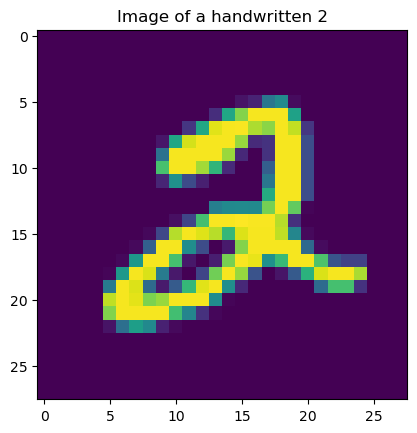

In [3]:
plt.imshow(X_train[5])
plt.title(f'Image of a handwritten {y_train[5]}');

In [4]:
# Accuracy of basic CNN with no augmentation

In [5]:
### GRADED
tf.random.set_seed(42)
model = ''
history = ''


### BEGIN SOLUTION
tf.random.set_seed(42)
model = Sequential([Flatten(),
                    Dense(60, activation = 'relu'),
                   Dense(10, activation = 'softmax')])
model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_train, Y_train, validation_data = (X_test, Y_test),
         verbose = 0,
                   epochs = 2)
### END SOLUTION

### ANSWER CHECK
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

0.9081500172615051
0.9132000207901001


In [6]:
#AUGMENT IMAGE
#Transform Image Dataset to "flip" and "rotate"
#Show Original Data and Augmented Data

<!-- #### Data Augmentation
One way to attempt a model improvement is to create new inputs to the network based on transformed versions of the original data.  

In the code cell below, use the `ImageDataGenerator` function from `keras` with the arguments `horizontal_flip` and `vertical_flip` both equal to `True` to create a new version of the train and test data that performs both a horizontal and vertical flip of the images. Assign this new object to the variable `gen` below.  

Perform the horizontal and vertical flips on the training sets by using the `.flow` method on `gen` with arguments `X_train` and `y_train`. Assign this new object to the variable `train_gen`.

Perform the horizontal and vertical flips on the testing sets by using the `.flow` method on `gen` with arguments `X_test` and `y_test`. Assign this new object to the variable `test_gen`. -->

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

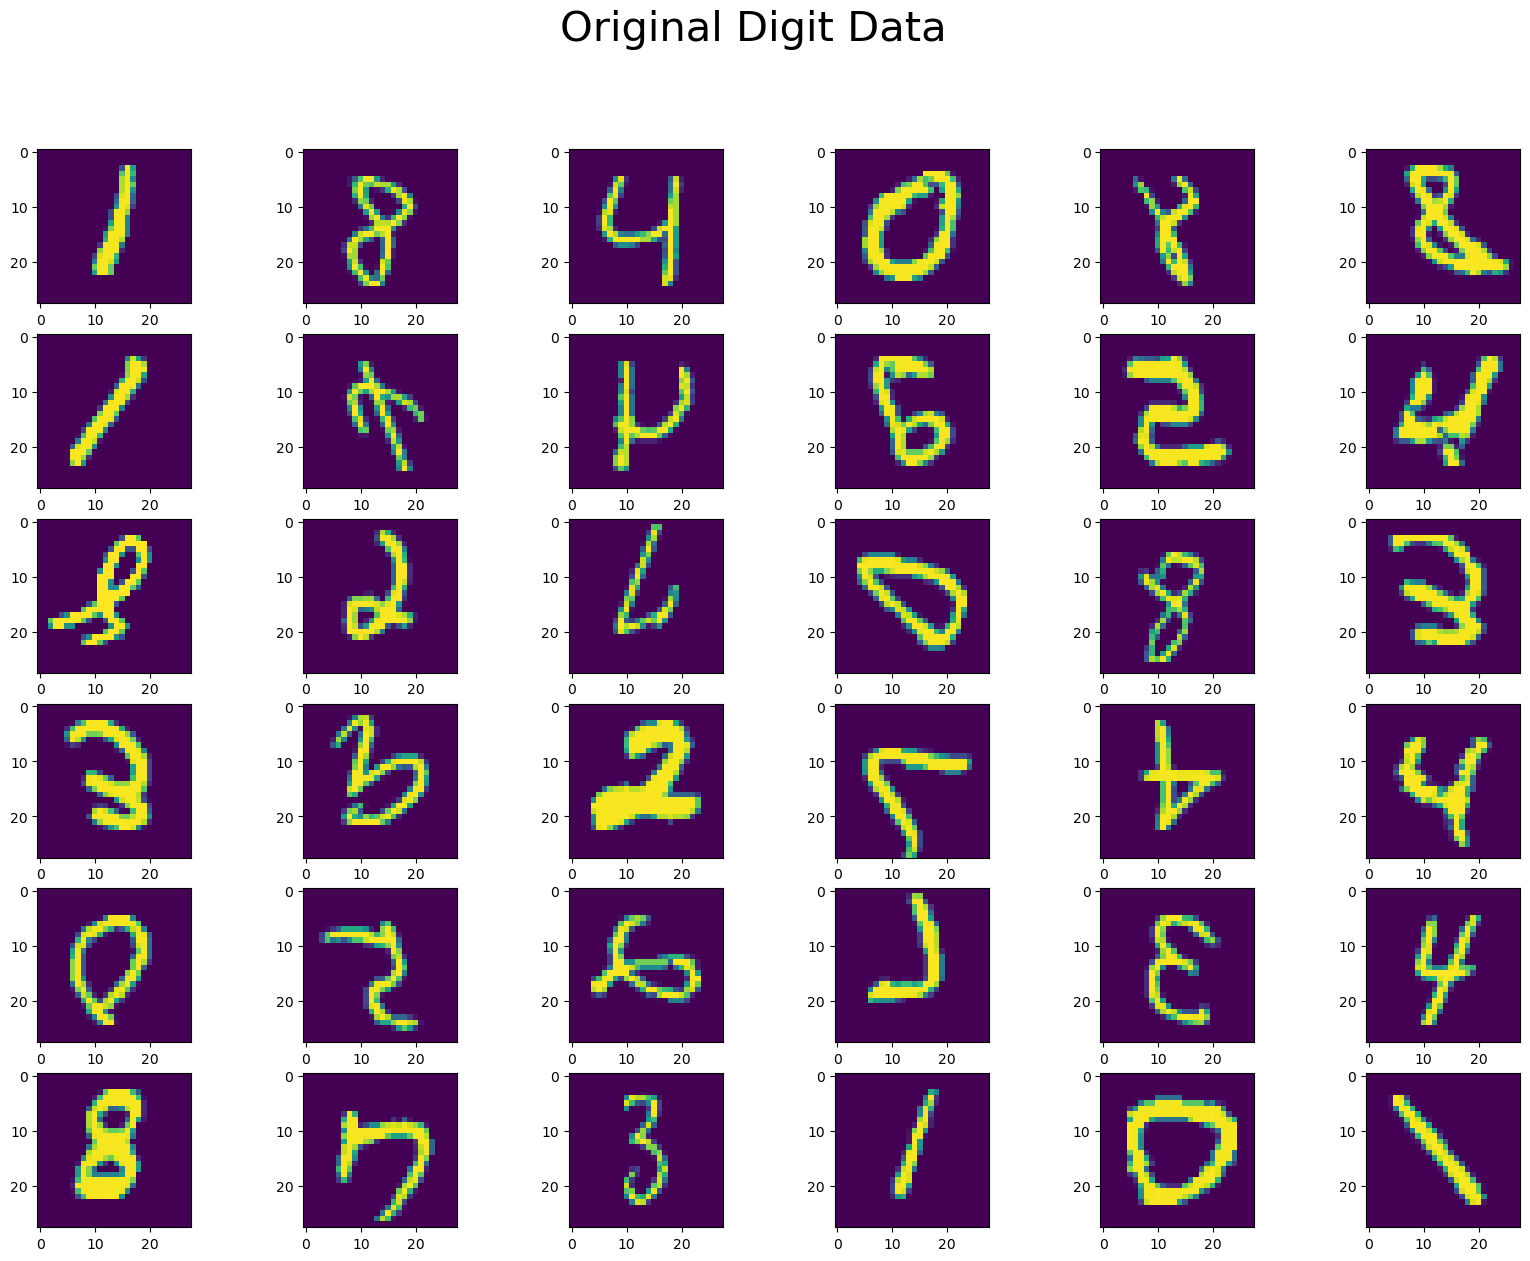

In [8]:
### GRAD

tf.random.set_seed(42)
gen = ''
train_gen = ''
test_gen = ''


### BEGIN SOLUTION
tf.random.set_seed(42)
gen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)
gen.fit(X_train)
train_gen = gen.flow(X_train, Y_train)
test_gen = gen.flow(X_test, Y_test)
### END SOLUTION

### ANSWER CHECK
#UNCOMMENT TO VISUALIZE
fig, ax = plt.subplots(6, 6, figsize = (20, 14))
for i in range(6):
    for j in range(6):
        pic = next(train_gen)
        ax[i, j].imshow(pic[0][0].reshape(28, 28))
plt.suptitle("Original Digit Data", fontsize = 30);

In [9]:
#Display Augmented Images

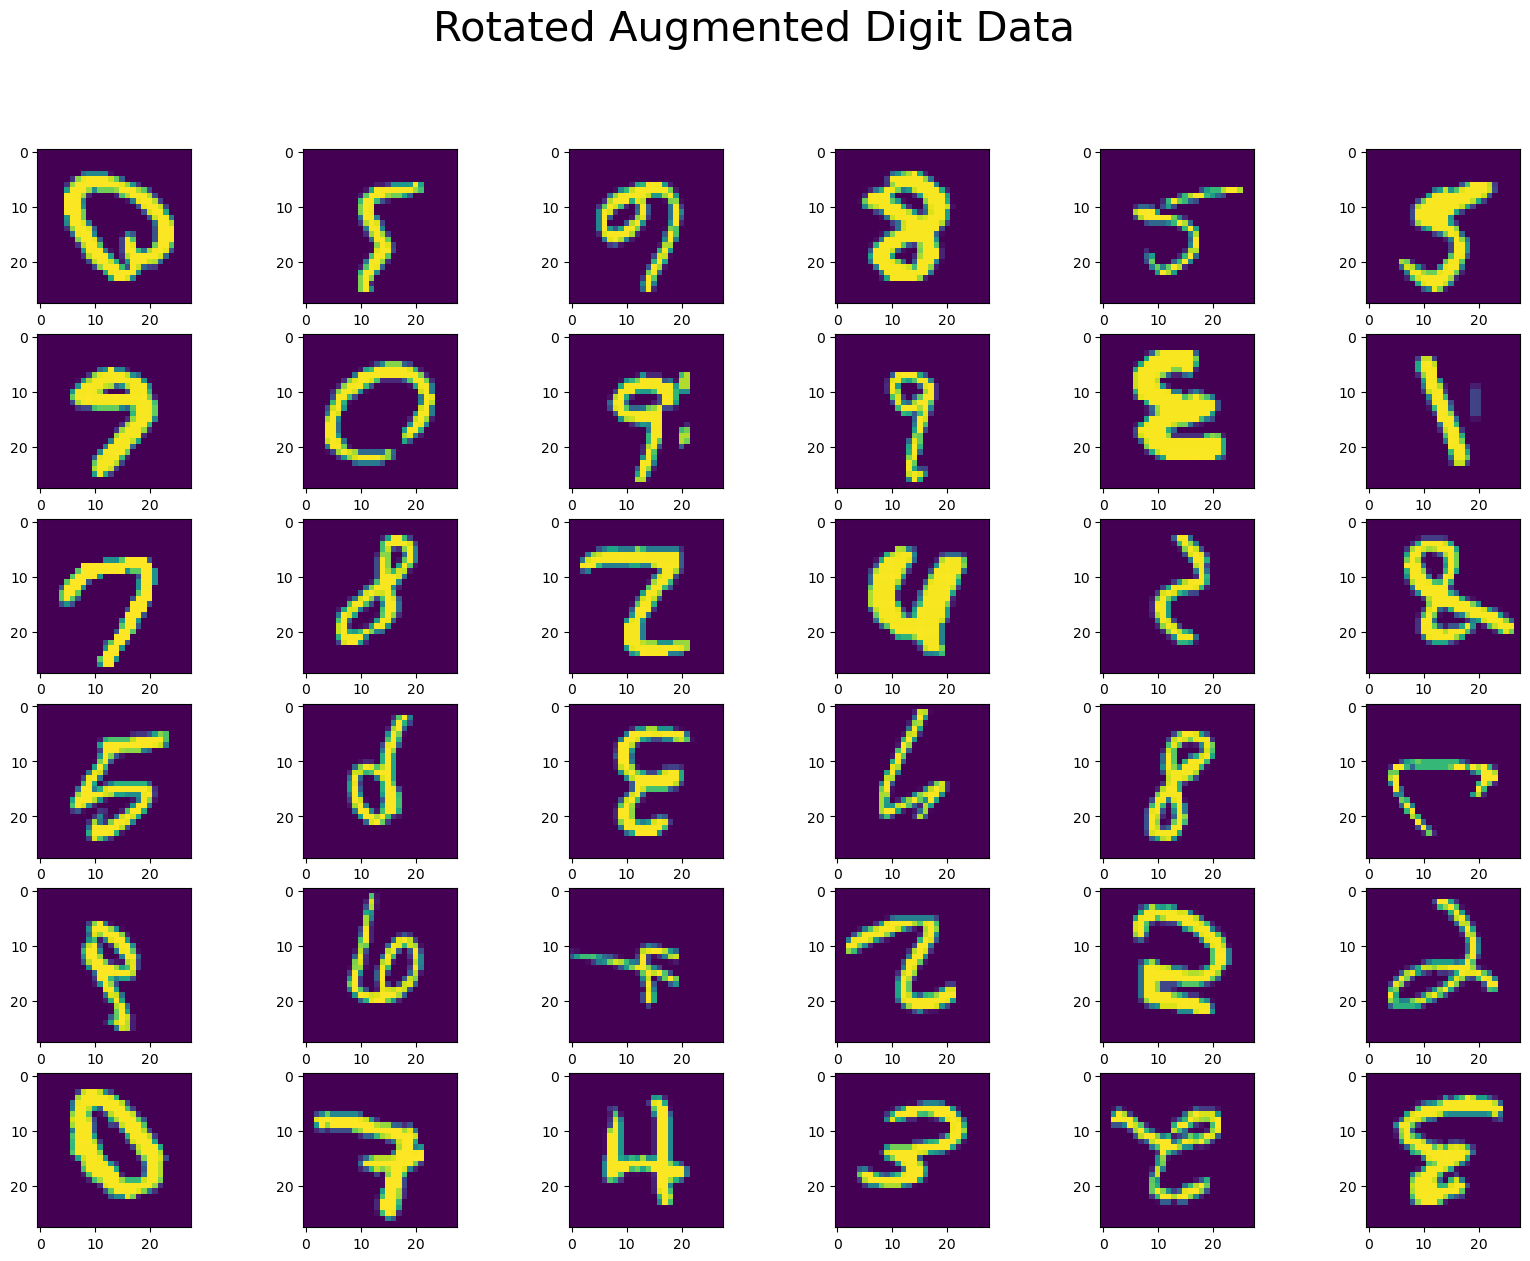

In [10]:
fig, ax = plt.subplots(6, 6, figsize = (20, 14))
for i in range(6):
    for j in range(6):
        pic = next(train_gen)
        ax[i, j].imshow(pic[0][0].reshape(28, 28))
plt.suptitle("Rotated Augmented Digit Data", fontsize = 30);

In [11]:
#Accuracy of Augmented Images

<!-- Compare the performance of the convolutional architecture on the augmented version of the data.  You can replace `X_train` and `X_test` in your model fitting with `train_gen` and `test_gen`.  

Create a new model, `aug_model`, with the identical architecture to the first network and compile it using the same settings as in **Problem 1**.

Fit your model to the data `train_gen` defined in and use `test_gen` as `validation_data`. In this step, set the variable `verbose` equal to `0` and the number of `epochs` equal to 2.

Assign the fit model to the `augmented_history` variable below. -->

In [12]:
### GRADED
tf.random.set_seed(42)
aug_model = ''
augmented_history = ''


### BEGIN SOLUTION
tf.random.set_seed(42)
aug_model = Sequential([Flatten(), Dense(60, activation = 'relu'),
                       Dense(10, activation = 'softmax')])
aug_model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'])
augmented_history = aug_model.fit(train_gen,  validation_data = test_gen,
                                 epochs = 2, verbose = 0)
### END SOLUTION

### ANSWER CHECK
print(augmented_history.history['accuracy'][-1])
print(augmented_history.history['val_accuracy'][-1])

0.5397166609764099
0.5996000170707703


# Run same model with images rotated (not flipped) at 40 degree increments

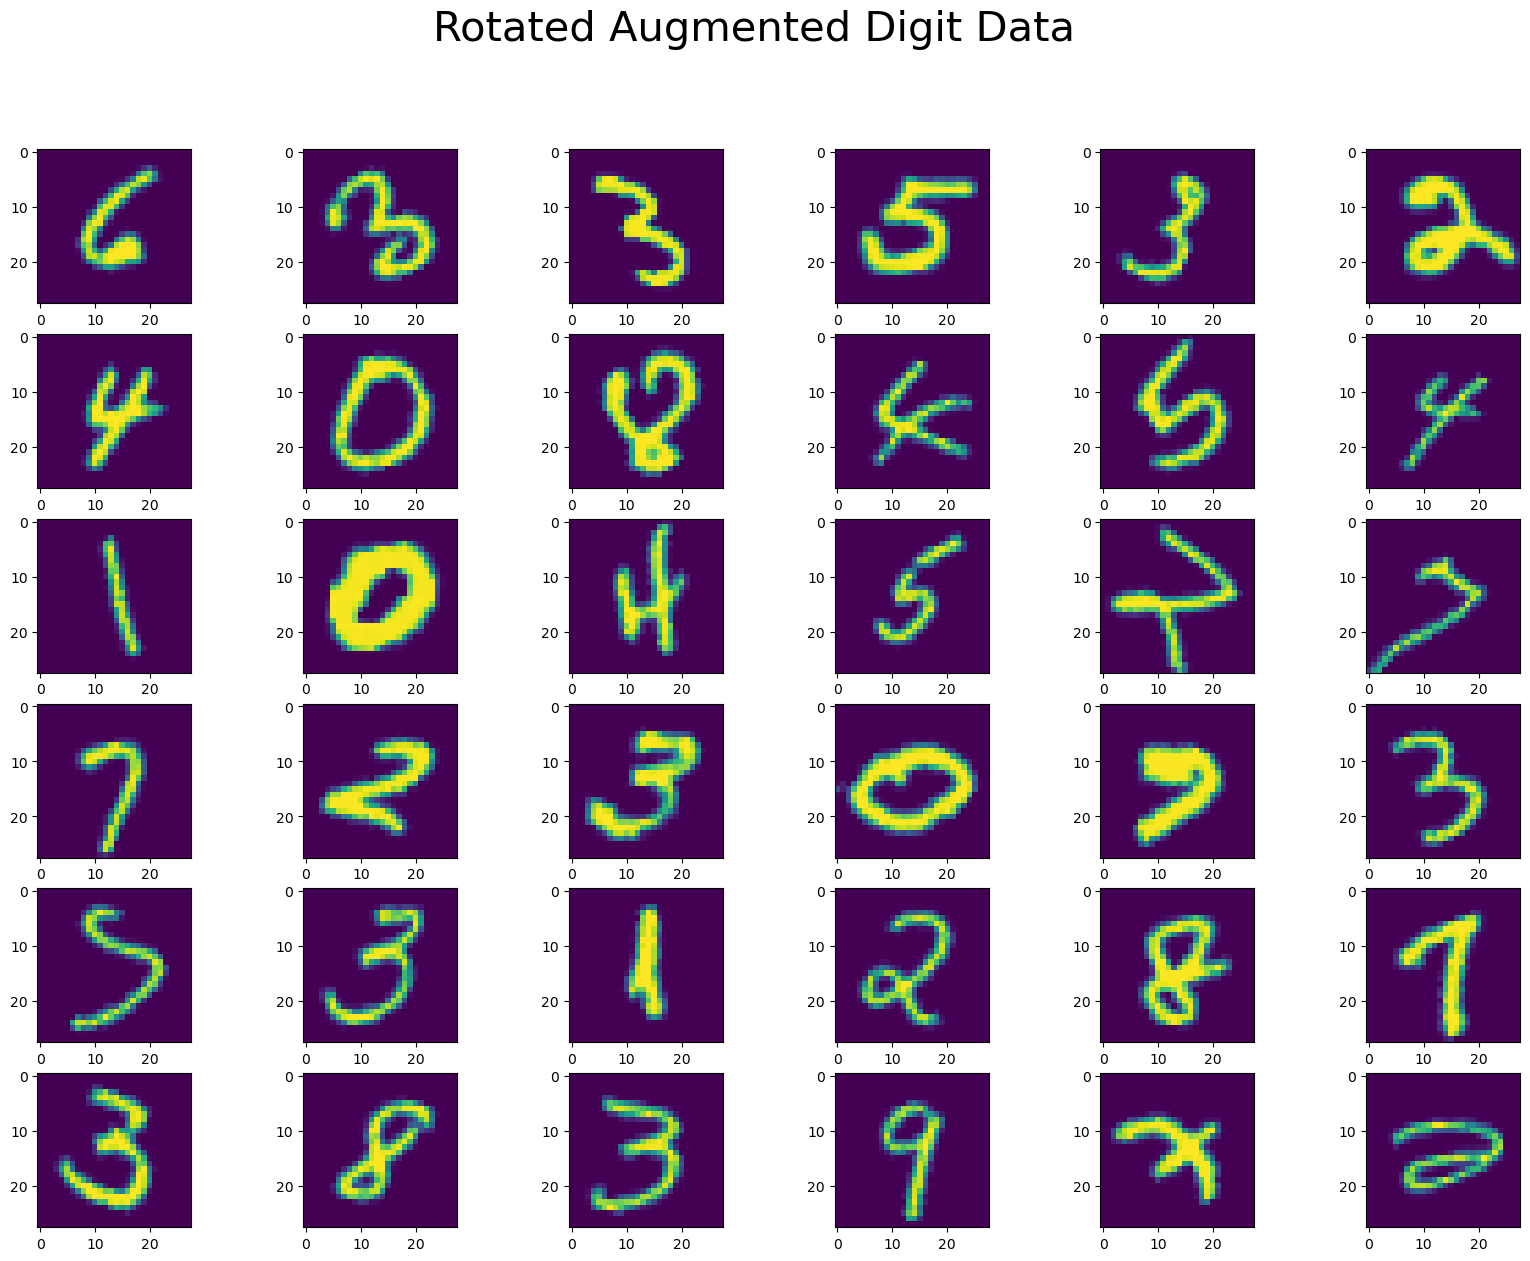

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)
gen = ImageDataGenerator(rotation_range=40)
gen.fit(X_train)
train_gen = gen.flow(X_train, Y_train)
test_gen = gen.flow(X_test, Y_test)

# Visualize the rotated images
fig, ax = plt.subplots(6, 6, figsize = (20, 14))
for i in range(6):
    for j in range(6):
        pic = next(train_gen)
        ax[i, j].imshow(pic[0][0].reshape(28, 28))
plt.suptitle("Rotated Augmented Digit Data", fontsize = 30);

In [14]:
### GRADED
tf.random.set_seed(42)
aug_model = ''
augmented_history = ''


### BEGIN SOLUTION
tf.random.set_seed(42)
aug_model = Sequential([Flatten(), Dense(60, activation = 'relu'),
                       Dense(10, activation = 'softmax')])
aug_model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'])
augmented_history = aug_model.fit(train_gen,  validation_data = test_gen,
                                 epochs = 2, verbose = 0)
### END SOLUTION

### ANSWER CHECK
print(augmented_history.history['accuracy'][-1])
print(augmented_history.history['val_accuracy'][-1])

0.7875166535377502
0.829200029373169
